In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("iris.csv", sep=",", quotechar='"')

df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


# Aufgabe 1

Histogram -> Häufigkeitsverteilung  
Wie häufig kommt ein Wert (x) vor (y). Die Farbe zeigt dabei, zu welcher Kategorie die einzelnen werte gehören


<Axes: ylabel='Frequency'>

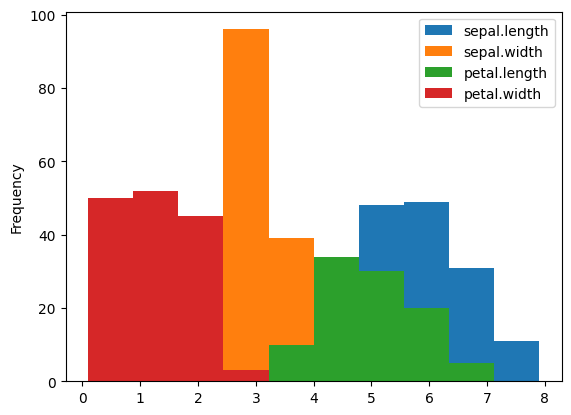

In [3]:
df.plot(kind="hist")

In [4]:
list(filter(lambda x: '.' in x, df.columns.tolist()))

['sepal.length', 'sepal.width', 'petal.length', 'petal.width']

In [5]:
# df.loc[x, y] get values in y that specified by x
df.loc[df["variety"] == "Setosa", "petal.width"]

0     0.2
1     0.2
2     0.2
3     0.2
4     0.2
5     0.4
6     0.3
7     0.2
8     0.2
9     0.1
10    0.2
11    0.2
12    0.1
13    0.1
14    0.2
15    0.4
16    0.4
17    0.3
18    0.3
19    0.3
20    0.2
21    0.4
22    0.2
23    0.5
24    0.2
25    0.2
26    0.4
27    0.2
28    0.2
29    0.2
30    0.2
31    0.4
32    0.1
33    0.2
34    0.2
35    0.2
36    0.2
37    0.1
38    0.2
39    0.2
40    0.3
41    0.3
42    0.2
43    0.6
44    0.4
45    0.3
46    0.2
47    0.2
48    0.2
49    0.2
Name: petal.width, dtype: float64

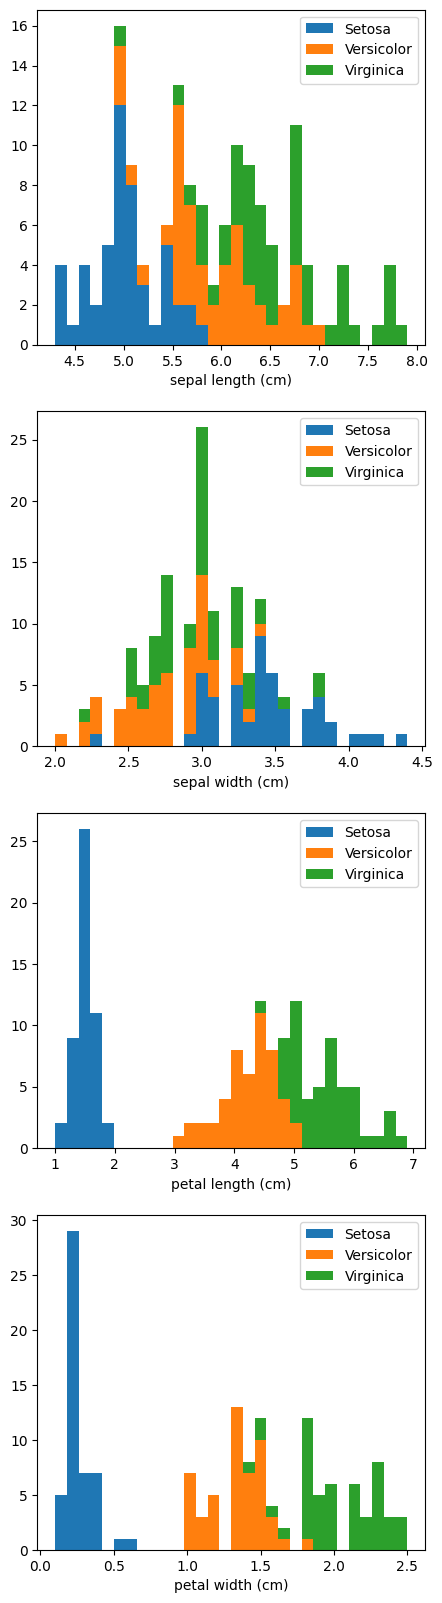

In [6]:
# df[["sepal.length", "variety"]].groupby("variety").plot(kind="hist", stacked=True)

types = df["variety"].unique()
parameters = list(filter(lambda x: '.' in x, df.columns.tolist()))

og_rcParms = plt.rcParams['figure.figsize']
plt.rcParams['figure.figsize'] = [5, 5 * len(parameters)]

_, ((plts)) = plt.subplots(len(parameters), 1)

for i, parameter in enumerate(parameters):
    data = [df.loc[df["variety"] == t, parameter] for t in types]
    plts[i].hist(data, stacked=True, bins=30)
    plts[i].legend(types)
    
    name = parameter.split(".")
    name = f'{name[0]} {name[1]} (cm)'
    plts[i].set_xlabel(name)

plt.rcParams['figure.figsize'] = og_rcParms

Text(0.5, 0, 'sepal length (cm)')

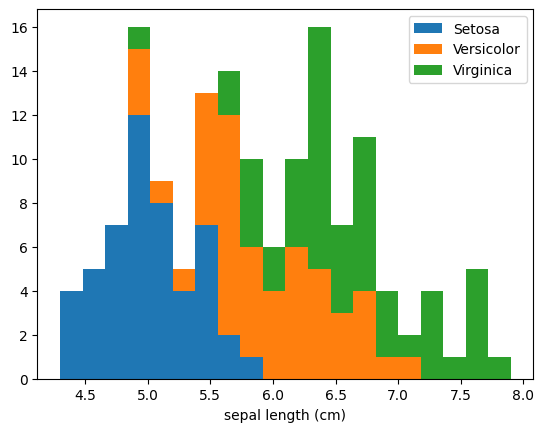

In [7]:
parameter = "sepal.length"
    
data = [df.loc[df["variety"] == t, parameter] for t in types]
plt.hist(data, stacked=True, bins=20)
plt.legend(types)

name = parameter.split(".")
name = f'{name[0]} {name[1]} (cm)'
plt.xlabel(name)

Text(0.5, 0, 'sepal width (cm)')

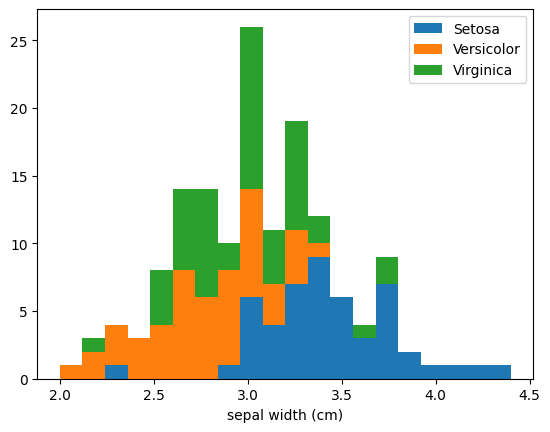

In [8]:
parameter = "sepal.width"
    
data = [df.loc[df["variety"] == t, parameter] for t in types]
plt.hist(data, stacked=True, bins=20)
plt.legend(types)

name = parameter.split(".")
name = f'{name[0]} {name[1]} (cm)'
plt.xlabel(name)

Text(0.5, 0, 'petal length (cm)')

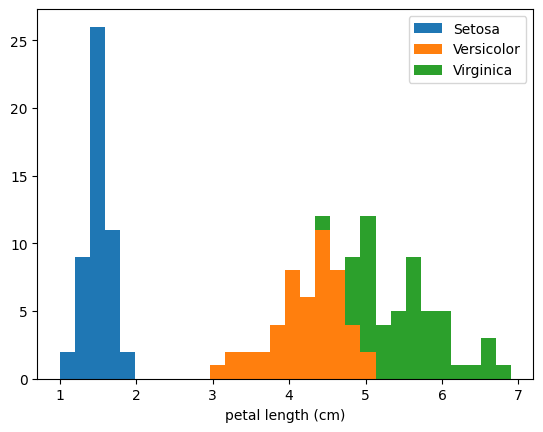

In [9]:
parameter = "petal.length"
    
data = [df.loc[df["variety"] == t, parameter] for t in types]
plt.hist(data, stacked=True, bins=30)
plt.legend(types)

name = parameter.split(".")
name = f'{name[0]} {name[1]} (cm)'
plt.xlabel(name)

Text(0.5, 0, 'petal width (cm)')

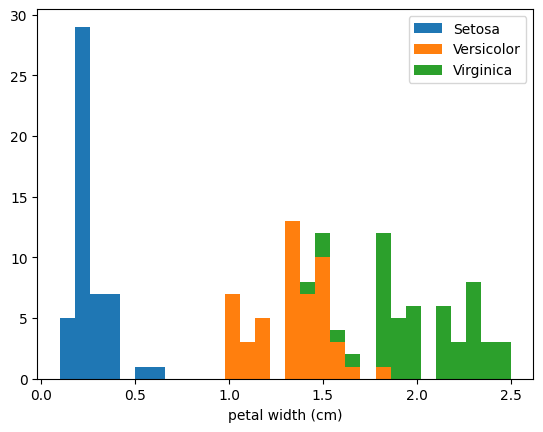

In [10]:
parameter = "petal.width"
    
data = [df.loc[df["variety"] == t, parameter] for t in types]
plt.hist(data, stacked=True, bins=30)
plt.legend(types)

name = parameter.split(".")
name = f'{name[0]} {name[1]} (cm)'
plt.xlabel(name)

# Aufgabe 2

Text(0, 0.5, 'sepal width (cm)')

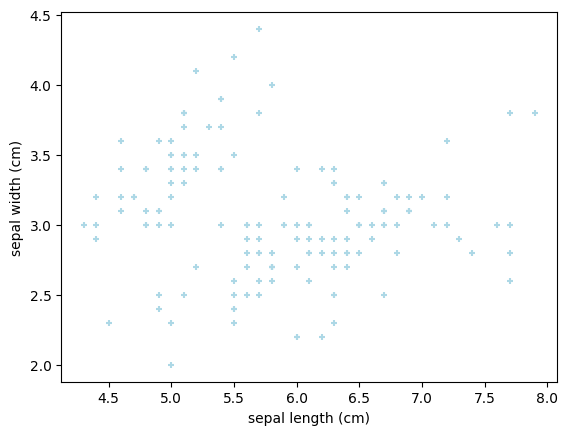

In [15]:
ax = df.plot.scatter(
    x='sepal.length',
    y='sepal.width',
    c='LightBlue',
    marker='+'
)
ax.set_xlabel('sepal length (cm)')
ax.set_ylabel('sepal width (cm)')

Text(0, 0.5, 'petal width (cm)')

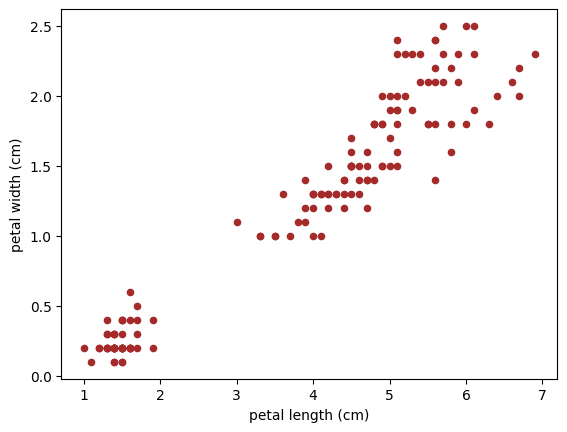

In [16]:
ax = df.plot.scatter(
    x='petal.length',
    y='petal.width',
    c='Brown'
)
ax.set_xlabel('petal length (cm)')
ax.set_ylabel('petal width (cm)')

## Aufgabe 2 b

**Korrelationskoeffizient**  
gibt es einen linearen zusammenhang zwischen den Attributen.


In [ ]:
r = df['sepal.length'].corr(df['sepal.width'])           # Pearson standardmäßig
f'The correlation coefficient between sepal length (cm) and sepal width (cm) attributes is {r}'

'The correlation coefficient between petal length (cm) and petal width (cm) attributes is -0.11756978413300208'

In [22]:
r = df['petal.length'].corr(df['petal.width'])           # Pearson standardmäßig
f'The correlation coefficient between petal length (cm) and petal width (cm) attributes is {r}'

'The correlation coefficient between petal length (cm) and petal width (cm) attributes is 0.9628654314027961'

# Aufgabe 3

In [24]:
sf = pd.read_csv("pvtest.csv")
sf[:10]

,Unnamed: 0,Time,Inverter,AcFreq,AcPower,Edaily,Eint,Etotal,Riso,Error,...,City_plant,Street_plant,Latitude_plant,Longitude_plant,ModulArea_plant,SpecificEnergyExpected_plant,StartupDate_plant,TotalPower_plant,string_id,tags
0,232,20.01.21 07:45,WR 3 Diehl,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN
1,233,20.01.21 07:50,WR 3 Diehl,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN
2,234,20.01.21 07:55,WR 3 Diehl,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN
3,235,20.01.21 08:00,WR 3 Diehl,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN
4,236,20.01.21 08:05,WR 3 Diehl,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN
5,237,20.01.21 08:15,WR 3 Diehl,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN
6,238,20.01.21 08:20,WR 3 Diehl,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN
7,239,20.01.21 08:25,WR 3 Diehl,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN
8,240,20.01.21 08:30,WR 3 Diehl,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN
9,241,20.01.21 08:35,WR 3 Diehl,NaN,11.0,0.0,NaN,NaN,NaN,NaN,...,Rüsselsheim,Lenbachstr. 17 - 27,49.988792,8.442296,417.18,900.0,31.10.12 00:00,61.74,600a4c362671ca676a1ece2855a46bb1,NaN


## Aufgabe 2 b

In [25]:
sf.columns.values

array(['Unnamed: 0', 'Time', 'Inverter', 'AcFreq', 'AcPower', 'Edaily',
       'Eint', 'Etotal', 'Riso', 'Error', 'Status', 'Temp1', 'Temp2',
       'Dci', 'Dcp', 'Dcu', 'Aci', 'Acp', 'Acu', 'Inverter_string',
       'StringNumber_string', 'Used_string', 'Azimuth_string',
       'Elevation_string', 'SingleModulePower_string',
       'StringCount_string', 'ModulesPerString_string',
       'ModulePower_string', 'Installation_string',
       'ModuleManufacturer_string', 'ModuleType_string',
       'AnalysisGroup_string', 'Inverter_inverter', 'Azimuth_inverter',
       'Elevation_inverter', 'Power_inverter', 'ModulePower_inverter',
       'InverterManufacturer_inverter', 'InverterType_inverter',
       'ModuleManufacturer_inverter', 'ModuleType_inverter',
       'AnalysisGroup_inverter', 'Plant_plant', 'PostalCode_plant',
       'City_plant', 'Street_plant', 'Latitude_plant', 'Longitude_plant',
       'ModulArea_plant', 'SpecificEnergyExpected_plant',
       'StartupDate_plant', 'TotalPowe

In [27]:
sf[['Dci', 'Dcp', 'Dcu', 'Temp1']][:10]

,Dci,Dcp,Dcu,Temp1
0,0.0,0,0,0.0
1,0.0,0,0,0.0
2,0.0,0,0,0.0
3,0.0,0,0,0.0
4,0.0,0,0,0.0
5,0.0,0,0,0.0
6,0.0,0,0,0.0
7,0.0,0,0,0.0
8,0.0,0,158,3.0
9,0.0,0,251,6.0


## Aufgabe 3 c

 * `.eq()` checks if a cell is equal and sets the cells value to True it it is
 * `.any(axis=1)` accumulates all bool in a direction, becoming true any value is true. axis=1 -> row | axis=0 -> column. (BC python devs are to stupid for proper function names / parameters)
 * ~ invertiert die liste.


In [45]:
reduced_sf = sf[['Dci', 'Dcp', 'Dcu', 'Temp1']][~sf.eq(0).any(axis=1)]
reduced_sf[:10]

,Dci,Dcp,Dcu,Temp1
10,0.005391,2,371,6.0
11,0.021505,10,465,6.0
12,0.034553,17,492,7.0
13,0.062147,33,531,8.0
14,0.088929,49,551,8.0
15,0.106572,60,563,8.0
16,0.117958,67,568,8.0
17,0.133100,76,571,8.0
18,0.157534,92,584,9.0
19,0.177172,104,587,10.0


In [48]:
corr = reduced_sf.corr()
corr

,Dci,Dcp,Dcu,Temp1
Dci,1.000000,0.999678,0.519512,0.690540
Dcp,0.999678,1.000000,0.520124,0.683678
Dcu,0.519512,0.520124,1.000000,0.548760
Temp1,0.690540,0.683678,0.548760,1.000000


<Axes: >

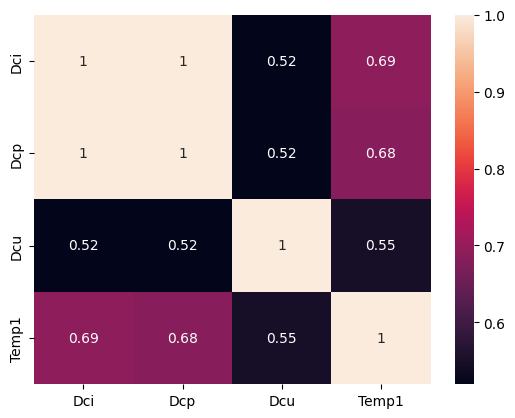

In [50]:


sns.heatmap(corr, annot=True)